In [25]:
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , TensorDataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)




cuda


In [26]:
transform = transforms.Compose([ transforms.Resize((64,64)), 
                                transforms.ToTensor(), 
                                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

from torchvision.datasets import CIFAR10

dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


In [27]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(
                z_dim,
                features_g * 8,
                kernel_size=4,
                stride=1,
                padding=0
            ),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                features_g * 8,
                features_g * 4,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                features_g * 4,
                features_g * 2,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                features_g * 2,
                features_g,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                features_g,
                channels_img,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)
    
class Discriminator(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                channels_img,
                features_d,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                features_d,
                features_d * 2,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                features_d * 2,
                features_d * 4,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                features_d * 4,
                features_d * 8,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                features_d * 8,
                1,
                kernel_size=4,
                stride=1,
                padding=0
            ),

        
        )

    def forward(self, x):
        return self.net(x)
    
def initialize_weights(model):
     for m in model.modules():

        if isinstance(m, (nn.Conv2d,
                          nn.ConvTranspose2d,
                          nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            
            
gen = Generator().to(device)

disc = Discriminator().to(device)

initialize_weights(gen)
initialize_weights(disc)
    

In [28]:
criterion = nn.BCEWithLogitsLoss()

opt_gen = torch.optim.Adam(
    gen.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

opt_disc = torch.optim.Adam(
    disc.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

In [29]:
gen.train()
disc.train()

epochs=50
for epoch in range(epochs):

    for batch_idx, (real, _) in enumerate(loader):

        real = real.to(device)
        batch_size = real.size(0)

        # =====================================
        # Train Discriminator
        # =====================================

        noise = torch.randn(
            batch_size,
            100,
            1,
            1,
            device=device
        )

        fake = gen(noise)

        disc_real = disc(real)
        disc_fake = disc(fake.detach())

        loss_real = criterion(
            disc_real,
            torch.ones_like(disc_real)
        )

        loss_fake = criterion(
            disc_fake,
            torch.zeros_like(disc_fake)
        )

        loss_disc = (loss_real + loss_fake) / 2

        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # =====================================
        # Train Generator
        # =====================================

        output = disc(fake)

        loss_gen = criterion(
            output,
            torch.ones_like(output)
        )

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        # =====================================
        # Logging
        # =====================================

        if batch_idx % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Batch [{batch_idx}/{len(loader)}] "
                f"Loss D: {loss_disc.item():.4f} "
                f"Loss G: {loss_gen.item():.4f}"
            )

Epoch [1/50] Batch [0/782] Loss D: 0.6951 Loss G: 0.8041
Epoch [1/50] Batch [100/782] Loss D: 0.0161 Loss G: 4.1153
Epoch [1/50] Batch [200/782] Loss D: 0.4680 Loss G: 1.4578
Epoch [1/50] Batch [300/782] Loss D: 0.3584 Loss G: 2.1155
Epoch [1/50] Batch [400/782] Loss D: 0.3326 Loss G: 2.1340
Epoch [1/50] Batch [500/782] Loss D: 0.4530 Loss G: 1.6565
Epoch [1/50] Batch [600/782] Loss D: 0.4591 Loss G: 2.0398
Epoch [1/50] Batch [700/782] Loss D: 0.5772 Loss G: 0.9775
Epoch [2/50] Batch [0/782] Loss D: 0.5300 Loss G: 2.0923
Epoch [2/50] Batch [100/782] Loss D: 0.4512 Loss G: 1.4167
Epoch [2/50] Batch [200/782] Loss D: 0.5223 Loss G: 1.2980
Epoch [2/50] Batch [300/782] Loss D: 0.5803 Loss G: 1.3797
Epoch [2/50] Batch [400/782] Loss D: 0.5731 Loss G: 1.4863
Epoch [2/50] Batch [500/782] Loss D: 0.4141 Loss G: 1.6820
Epoch [2/50] Batch [600/782] Loss D: 0.3758 Loss G: 1.4419
Epoch [2/50] Batch [700/782] Loss D: 0.4104 Loss G: 1.8698
Epoch [3/50] Batch [0/782] Loss D: 0.5591 Loss G: 2.0967
Epo

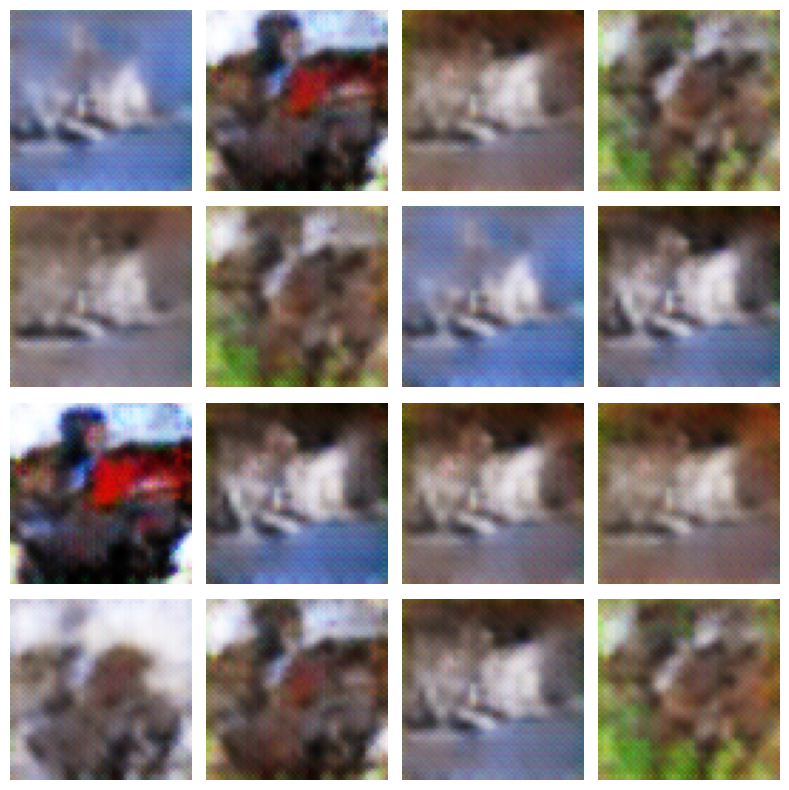

In [31]:
import torch
import matplotlib.pyplot as plt

gen.eval()

with torch.no_grad():

    noise = torch.randn(
        16,
        100,
        1,
        1,
        device=device
    )

    fake_images = gen(noise)

fake_images = fake_images.cpu()

# Convert from [-1,1] -> [0,1]
fake_images = (fake_images + 1) / 2

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i in range(16):

    row = i // 4
    col = i % 4

    axes[row, col].imshow(
        fake_images[i].permute(1, 2, 0)
    )

    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Dataset size:", len(dataset))
print("Number of batches:", len(loader))

Dataset size: 25
Number of batches: 1
